# Distilling the Knowledge in a Neural Network — From Scratch**Paper:** Hinton, Vinyals, Dean (2015). *Distilling the Knowledge in a Neural Network.* arXiv:1503.02531This notebook implements knowledge distillation from scratch in PyTorch. We train a large **teacher** MLP on MNIST, then train a smaller **student** MLP three ways:1. **Hard labels only** — standard cross-entropy training (baseline)2. **Distillation only** — soft targets from the teacher at high temperature3. **Combined** — weighted mix of soft + hard targets (the paper's recommended approach)We visualize the teacher's "dark knowledge" (soft probability distributions) and compare student accuracy across conditions and temperatures.> **Note:** This notebook is CPU-friendly. No GPU is required.

## 1. Imports & Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import copy
import time

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device — CPU only for this notebook
device = torch.device('cpu')
print(f"Device: {device}")

Device: cpu


## 2. Data Loading — MNIST

In [2]:
# MNIST with standard normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

Train samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


## 3. Teacher Network (Large MLP)A large MLP with two 800-unit hidden layers and dropout regularization, matching the paper's smaller-network baseline (the paper used 1200 units for the teacher and 800 for the student; we scale down slightly for CPU efficiency).

In [3]:
class TeacherNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 800)
        self.fc2 = nn.Linear(800, 800)
        self.fc3 = nn.Linear(800, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten (B, 1, 28, 28) -> (B, 784)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)  # logits
        return x

teacher = TeacherNet().to(device)
n_params = sum(p.numel() for p in teacher.parameters())
print(f"Teacher parameters: {n_params:,}")

Teacher parameters: 1,276,810


## 4. Student Network (Small MLP)A smaller MLP with two 300-unit hidden layers and **no dropout**. The student is ~5x smaller than the teacher. We deliberately omit dropout to show that distillation itself acts as a regularizer.

In [4]:
class StudentNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 300)
        self.fc2 = nn.Linear(300, 300)
        self.fc3 = nn.Linear(300, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

student_template = StudentNet().to(device)
n_params_s = sum(p.numel() for p in student_template.parameters())
print(f"Student parameters: {n_params_s:,}")
teacher_params = sum(p.numel() for p in teacher.parameters())
print(f"Teacher / Student parameter ratio: {teacher_params / n_params_s:.1f}x")

Student parameters: 328,810
Teacher / Student parameter ratio: 3.9x


## 5. Softmax with Temperature — From ScratchThe key mechanism of distillation: raising the softmax temperature produces a softer probability distribution, revealing the teacher's "dark knowledge" — the relative probabilities it assigns to incorrect classes.$$q_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$At T=1 this is the standard softmax. At higher T, the distribution becomes softer and more uniform, making small probabilities more learnable.

In [5]:
def softmax_with_temperature(logits, T=1.0):
    """Compute temperature-scaled softmax from scratch."""
    scaled_logits = logits / T
    # Subtract max for numerical stability
    max_vals, _ = torch.max(scaled_logits, dim=1, keepdim=True)
    exp_logits = torch.exp(scaled_logits - max_vals)
    soft_probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
    return soft_probs

# Demonstrate temperature effect on sample logits
demo_logits = torch.tensor([[10.0, 3.0, 1.0, 0.5, -1.0, -2.0, -3.0, -4.0, -5.0, -6.0]])
probs_dict = {}
for T in [1, 2, 5, 10]:
    probs_dict[T] = softmax_with_temperature(demo_logits, T=T)[0]

print("Effect of temperature on softmax output:")
header = f"{'Class':>5} | {'T=1':>10} | {'T=2':>10} | {'T=5':>10} | {'T=10':>10}"
print(header)
print("-" * 55)
for i in range(10):
    row = f"{i:>5}"
    for T in [1, 2, 5, 10]:
        row += f" | {probs_dict[T][i]:.6f}"
    print(row)

Effect of temperature on softmax output:
Class |        T=1 |        T=2 |        T=5 |       T=10
-------------------------------------------------------
    0 | 0.998865 | 0.943550 | 0.502862 | 0.258524
    1 | 0.000911 | 0.028493 | 0.124004 | 0.128379
    2 | 0.000123 | 0.010482 | 0.083122 | 0.105108
    3 | 0.000075 | 0.008163 | 0.075212 | 0.099982
    4 | 0.000017 | 0.003856 | 0.055719 | 0.086055
    5 | 0.000006 | 0.002339 | 0.045619 | 0.077866
    6 | 0.000002 | 0.001419 | 0.037349 | 0.070456
    7 | 0.000001 | 0.000860 | 0.030579 | 0.063751
    8 | 0.000000 | 0.000522 | 0.025036 | 0.057684
    9 | 0.000000 | 0.000317 | 0.020498 | 0.052195


## 6. Distillation Loss — From ScratchThe distillation loss is the Kullback-Leibler (KL) divergence between the teacher's soft target distribution and the student's soft prediction distribution, both computed at the same temperature T.The combined objective (from the paper):$$L = \alpha \cdot T^2 \cdot \text{KL}(p^{teacher}_T \| q^{student}_T) + (1 - \alpha) \cdot \text{CE}(y, q^{student}_1)$$The $T^2$ factor compensates for the $1/T^2$ scaling of the soft-target gradients.

In [6]:
def distillation_loss(student_logits, teacher_logits, T):
    """
    KL divergence between teacher and student soft distributions at temperature T.
    We use F.kl_div which computes KL(input || target) in log-space.
    """
    # Soft targets from teacher
    teacher_log_soft = F.log_softmax(teacher_logits / T, dim=1)
    student_log_soft = F.log_softmax(student_logits / T, dim=1)
    teacher_soft = F.softmax(teacher_logits / T, dim=1)
    
    # KL(teacher || student) = sum(teacher_soft * (log_teacher - log_student))
    kl = F.kl_div(student_log_soft, teacher_soft, reduction='batchmean')
    
    # Scale by T^2 as per the paper
    return kl * (T ** 2)


def combined_loss(student_logits, teacher_logits, labels, T, alpha):
    """
    Combined distillation + hard-label loss.
    alpha: weight on soft (distillation) loss; (1-alpha) on hard loss.
    """
    soft_loss = distillation_loss(student_logits, teacher_logits, T)
    hard_loss = F.cross_entropy(student_logits, labels)
    return alpha * soft_loss + (1 - alpha) * hard_loss


# Quick sanity check
dummy_student = torch.randn(4, 10)
dummy_teacher = torch.randn(4, 10)
dummy_labels = torch.tensor([0, 1, 2, 3])
loss_val = combined_loss(dummy_student, dummy_teacher, dummy_labels, T=4, alpha=0.7)
print(f"Sanity check - combined loss: {loss_val.item():.4f}")
print(f"  Soft loss (T=4): {distillation_loss(dummy_student, dummy_teacher, T=4).item():.4f}")
print(f"  Hard loss: {F.cross_entropy(dummy_student, dummy_labels).item():.4f}")

Sanity check - combined loss: 1.3859
  Soft loss (T=4): 0.7273
  Hard loss: 2.9227


## 7. Training & Evaluation Utilities

In [7]:
def evaluate(model, test_loader, device):
    """Evaluate model accuracy on test set."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = outputs.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
    return 100.0 * correct / total


def get_soft_predictions(model, data_loader, device, T=1.0, max_batches=None):
    """Get the model's soft predictions for visualization."""
    model.eval()
    all_soft = []
    all_labels = []
    all_images = []
    with torch.no_grad():
        for i, (data, target) in enumerate(data_loader):
            if max_batches and i >= max_batches:
                break
            data, target = data.to(device), target.to(device)
            logits = model(data)
            soft = softmax_with_temperature(logits, T=T)
            all_soft.append(soft.cpu())
            all_labels.append(target.cpu())
            all_images.append(data.cpu())
    return torch.cat(all_soft), torch.cat(all_labels), torch.cat(all_images)


def train_model(model, train_loader, test_loader, device, epochs=10, lr=0.001,
                loss_type='hard', teacher_model=None, T=4.0, alpha=0.7):
    """
    Train a model with one of three loss types:
    - 'hard': standard cross-entropy with hard labels
    - 'distill': distillation loss only (soft targets from teacher)
    - 'combined': weighted combination of soft + hard losses
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    test_accs = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            
            student_logits = model(data)
            
            if loss_type == 'hard':
                loss = F.cross_entropy(student_logits, target)
            elif loss_type == 'distill':
                with torch.no_grad():
                    teacher_logits = teacher_model(data)
                loss = distillation_loss(student_logits, teacher_logits, T)
            elif loss_type == 'combined':
                with torch.no_grad():
                    teacher_logits = teacher_model(data)
                loss = combined_loss(student_logits, teacher_logits, target, T, alpha)
            else:
                raise ValueError(f"Unknown loss_type: {loss_type}")
            
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        
        avg_loss = epoch_loss / n_batches
        acc = evaluate(model, test_loader, device)
        train_losses.append(avg_loss)
        test_accs.append(acc)
        print(f"  Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Test Acc: {acc:.2f}%")
    
    return train_losses, test_accs

## 8. Training the TeacherFirst, we train the large teacher network with standard cross-entropy and dropout.

In [8]:
print("=" * 60)
print("Training Teacher Network (800-800-10 with Dropout)")
print("=" * 60)
start = time.time()
teacher_train_losses, teacher_test_accs = train_model(
    teacher, train_loader, test_loader, device,
    epochs=10, lr=0.001, loss_type='hard'
)
teacher_time = time.time() - start
teacher_acc = evaluate(teacher, test_loader, device)
print()
print(f"Teacher final test accuracy: {teacher_acc:.2f}% (training time: {teacher_time:.1f}s)")

Training Teacher Network (800-800-10 with Dropout)


  Epoch 1/10 - Loss: 0.2962, Test Acc: 96.68%


  Epoch 2/10 - Loss: 0.1588, Test Acc: 96.87%


  Epoch 3/10 - Loss: 0.1310, Test Acc: 97.41%


  Epoch 4/10 - Loss: 0.1174, Test Acc: 97.51%


...

  Epoch 7/10 - Loss: 0.0939, Test Acc: 98.08%


  Epoch 8/10 - Loss: 0.0905, Test Acc: 97.92%


  Epoch 9/10 - Loss: 0.0869, Test Acc: 98.10%


  Epoch 10/10 - Loss: 0.0807, Test Acc: 98.12%



Teacher final test accuracy: 98.12% (training time: 25.9s)


## 9. Training Students — Three ConditionsNow we train three identical student networks under different conditions:1. **Hard labels only** — baseline2. **Distillation only** — soft targets from teacher at T=43. **Combined** — alpha=0.7 (70% soft, 30% hard) at T=4

In [9]:
# Student 1: Hard labels only
print("=" * 60)
print("Student 1: Hard Labels Only (baseline)")
print("=" * 60)
student_hard = StudentNet().to(device)
torch.manual_seed(42)
start = time.time()
hard_losses, hard_accs = train_model(
    student_hard, train_loader, test_loader, device,
    epochs=10, lr=0.001, loss_type='hard'
)
hard_time = time.time() - start
hard_acc = evaluate(student_hard, test_loader, device)
print()
print(f"Student (hard) final test accuracy: {hard_acc:.2f}% (time: {hard_time:.1f}s)")

Student 1: Hard Labels Only (baseline)


  Epoch 1/10 - Loss: 0.2446, Test Acc: 96.00%


  Epoch 2/10 - Loss: 0.0927, Test Acc: 96.91%


  Epoch 3/10 - Loss: 0.0636, Test Acc: 97.40%


  Epoch 4/10 - Loss: 0.0457, Test Acc: 97.55%


...

  Epoch 7/10 - Loss: 0.0237, Test Acc: 97.99%


  Epoch 8/10 - Loss: 0.0230, Test Acc: 98.34%


  Epoch 9/10 - Loss: 0.0203, Test Acc: 98.09%


  Epoch 10/10 - Loss: 0.0181, Test Acc: 98.13%



Student (hard) final test accuracy: 98.13% (time: 20.2s)


In [10]:
# Student 2: Distillation only (soft targets, T=4)
print("=" * 60)
print("Student 2: Distillation Only (T=4, soft targets)")
print("=" * 60)
student_distill = StudentNet().to(device)
torch.manual_seed(42)
start = time.time()
distill_losses, distill_accs = train_model(
    student_distill, train_loader, test_loader, device,
    epochs=10, lr=0.001, loss_type='distill', teacher_model=teacher, T=4.0
)
distill_time = time.time() - start
distill_acc = evaluate(student_distill, test_loader, device)
print()
print(f"Student (distill) final test accuracy: {distill_acc:.2f}% (time: {distill_time:.1f}s)")

Student 2: Distillation Only (T=4, soft targets)


  Epoch 1/10 - Loss: 2.3828, Test Acc: 96.19%


  Epoch 2/10 - Loss: 0.3789, Test Acc: 97.44%


  Epoch 3/10 - Loss: 0.2080, Test Acc: 97.51%


  Epoch 4/10 - Loss: 0.1478, Test Acc: 97.60%


...

  Epoch 7/10 - Loss: 0.0916, Test Acc: 97.90%


  Epoch 8/10 - Loss: 0.0828, Test Acc: 97.82%


  Epoch 9/10 - Loss: 0.0773, Test Acc: 97.84%


  Epoch 10/10 - Loss: 0.0718, Test Acc: 97.98%



Student (distill) final test accuracy: 97.98% (time: 22.9s)


In [11]:
# Student 3: Combined loss (alpha=0.7, T=4)
print("=" * 60)
print("Student 3: Combined Loss (alpha=0.7, T=4)")
print("=" * 60)
student_combined = StudentNet().to(device)
torch.manual_seed(42)
start = time.time()
combined_losses, combined_accs = train_model(
    student_combined, train_loader, test_loader, device,
    epochs=10, lr=0.001, loss_type='combined', teacher_model=teacher, T=4.0, alpha=0.7
)
combined_time = time.time() - start
combined_acc = evaluate(student_combined, test_loader, device)
print()
print(f"Student (combined) final test accuracy: {combined_acc:.2f}% (time: {combined_time:.1f}s)")

Student 3: Combined Loss (alpha=0.7, T=4)


  Epoch 1/10 - Loss: 1.7809, Test Acc: 96.36%


  Epoch 2/10 - Loss: 0.3020, Test Acc: 97.36%


  Epoch 3/10 - Loss: 0.1699, Test Acc: 97.69%


  Epoch 4/10 - Loss: 0.1217, Test Acc: 97.69%


...

  Epoch 7/10 - Loss: 0.0769, Test Acc: 97.89%


  Epoch 8/10 - Loss: 0.0709, Test Acc: 97.86%


  Epoch 9/10 - Loss: 0.0653, Test Acc: 97.86%


  Epoch 10/10 - Loss: 0.0617, Test Acc: 97.94%



Student (combined) final test accuracy: 97.94% (time: 23.5s)


## 10. Dark Knowledge VisualizationLet's look at what the teacher "knows" beyond the correct answer. We show the teacher's soft predictions for sample test images at different temperatures. The small probabilities assigned to incorrect classes encode the similarity structure — this is the "dark knowledge" that distillation transfers.

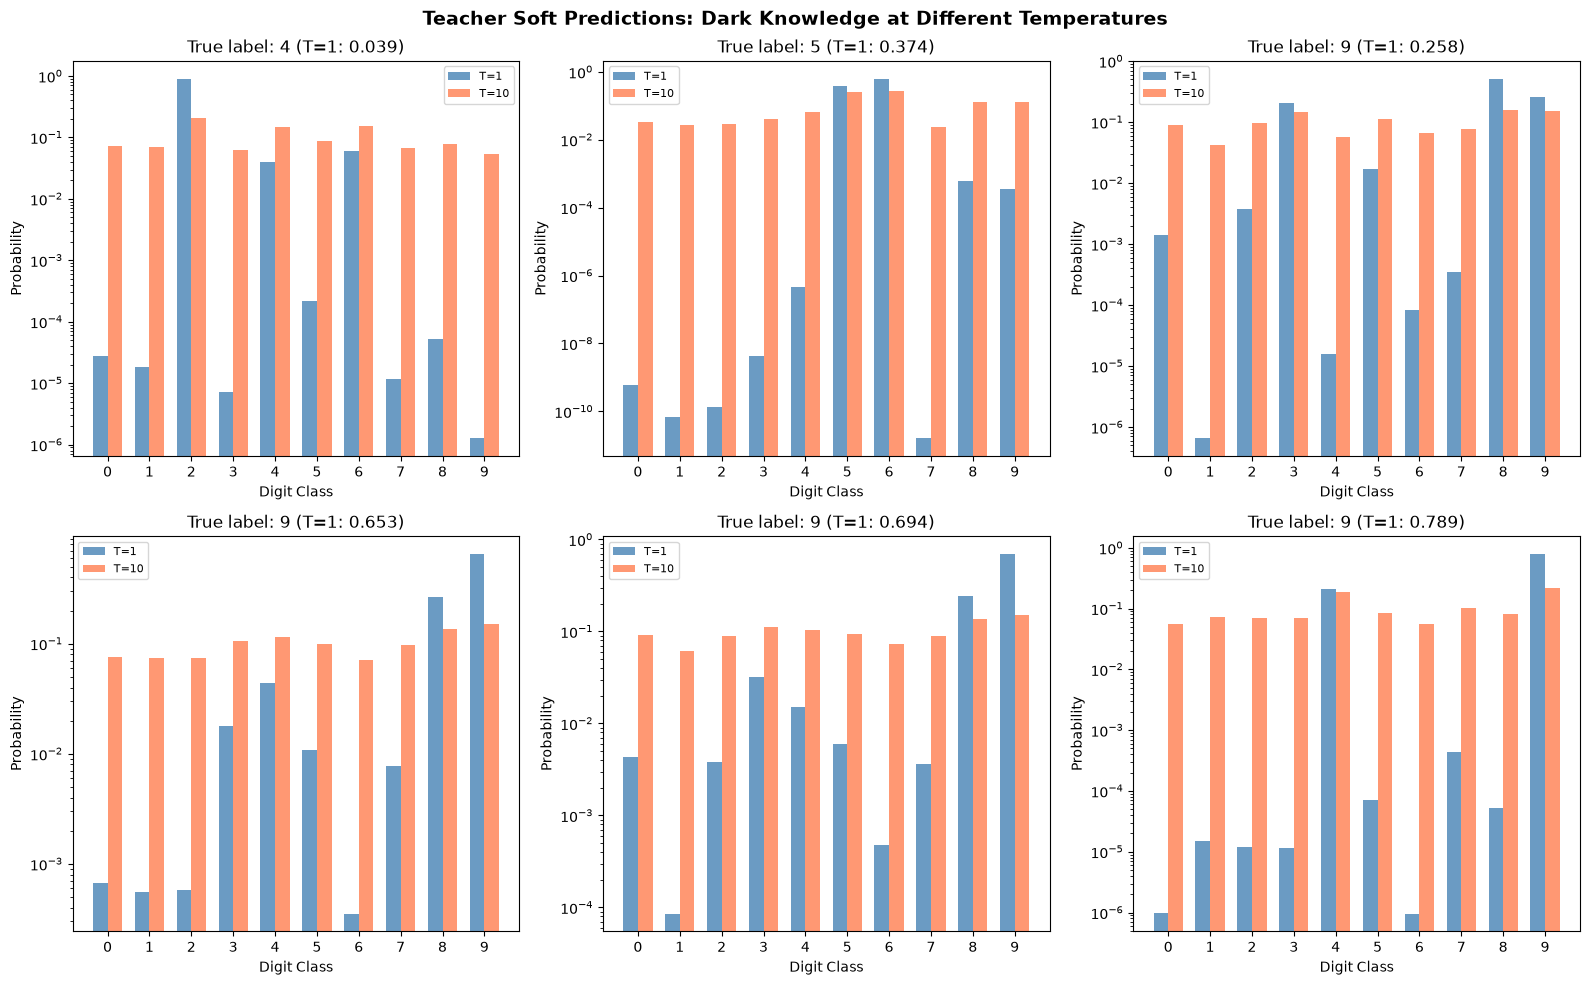


The log-scale y-axis reveals that at T=1, the teacher assigns small but
non-trivial probabilities to incorrect classes - this is the dark knowledge.
At T=10, these probabilities become more pronounced and learnable.


In [12]:
# Get teacher predictions on a batch of test images
soft_T1, labels_T1, images_T1 = get_soft_predictions(teacher, test_loader, device, T=1.0, max_batches=1)
soft_T10, _, _ = get_soft_predictions(teacher, test_loader, device, T=10.0, max_batches=1)

# Pick 6 interesting samples (where the teacher has non-trivial secondary probabilities)
secondary_probs = soft_T1.clone()
for i in range(len(labels_T1)):
    secondary_probs[i, labels_T1[i]] = 0  # zero out correct class
max_secondary = secondary_probs.max(dim=1)[0]
_, top_indices = torch.topk(max_secondary, 6)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx_idx, idx in enumerate(top_indices):
    row, col = idx_idx // 3, idx_idx % 3
    ax = axes[row][col]
    
    true_label = labels_T1[idx].item()
    probs_T1 = soft_T1[idx].numpy()
    probs_T10 = soft_T10[idx].numpy()
    
    x = np.arange(10)
    width = 0.35
    ax.bar(x - width/2, probs_T1, width, label='T=1', color='steelblue', alpha=0.8)
    ax.bar(x + width/2, probs_T10, width, label='T=10', color='coral', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xlabel('Digit Class')
    ax.set_ylabel('Probability')
    ax.set_title(f'True label: {true_label} (T=1: {probs_T1[true_label]:.3f})')
    ax.legend(fontsize=8)
    ax.set_yscale('log')

plt.suptitle('Teacher Soft Predictions: Dark Knowledge at Different Temperatures', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dark_knowledge.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print("The log-scale y-axis reveals that at T=1, the teacher assigns small but")
print("non-trivial probabilities to incorrect classes - this is the dark knowledge.")
print("At T=10, these probabilities become more pronounced and learnable.")

## 11. Temperature Sensitivity ExperimentThe paper shows that the optimal temperature depends on student capacity. Let's test several temperatures and see which works best for our 300-unit student.

In [13]:
temperatures = [1, 2, 4, 8, 16, 20]
temp_accs = []

print("=" * 60)
print("Temperature Sensitivity Experiment (combined loss, alpha=0.7)")
print("=" * 60)

for T in temperatures:
    print(f"--- Temperature T={T} ---")
    torch.manual_seed(42)
    student_temp = StudentNet().to(device)
    _, accs = train_model(
        student_temp, train_loader, test_loader, device,
        epochs=10, lr=0.001, loss_type='combined',
        teacher_model=teacher, T=float(T), alpha=0.7
    )
    final_acc = accs[-1]
    temp_accs.append(final_acc)
    print(f"  T={T}: Final accuracy = {final_acc:.2f}%")
    print()

print("=" * 60)
print("Temperature Sensitivity Results:")
print(f"{'T':>5} | {'Accuracy':>10}")
print("-" * 20)
for T, acc in zip(temperatures, temp_accs):
    print(f"{T:>5} | {acc:>9.2f}%")

Temperature Sensitivity Experiment (combined loss, alpha=0.7)
--- Temperature T=1 ---


  Epoch 1/10 - Loss: 0.2085, Test Acc: 96.48%


  Epoch 2/10 - Loss: 0.0664, Test Acc: 97.08%


  Epoch 3/10 - Loss: 0.0431, Test Acc: 97.47%


  Epoch 4/10 - Loss: 0.0313, Test Acc: 97.66%


...

  Epoch 6/10 - Loss: 0.2338, Test Acc: 97.94%


  Epoch 7/10 - Loss: 0.2167, Test Acc: 97.76%


  Epoch 8/10 - Loss: 0.2015, Test Acc: 97.79%


  Epoch 9/10 - Loss: 0.1919, Test Acc: 97.93%


  Epoch 10/10 - Loss: 0.1771, Test Acc: 97.93%
  T=20: Final accuracy = 97.93%

Temperature Sensitivity Results:
    T |   Accuracy
--------------------
    1 |     97.79%
    2 |     98.14%
    4 |     97.91%
    8 |     97.88%
   16 |     97.90%
   20 |     97.93%


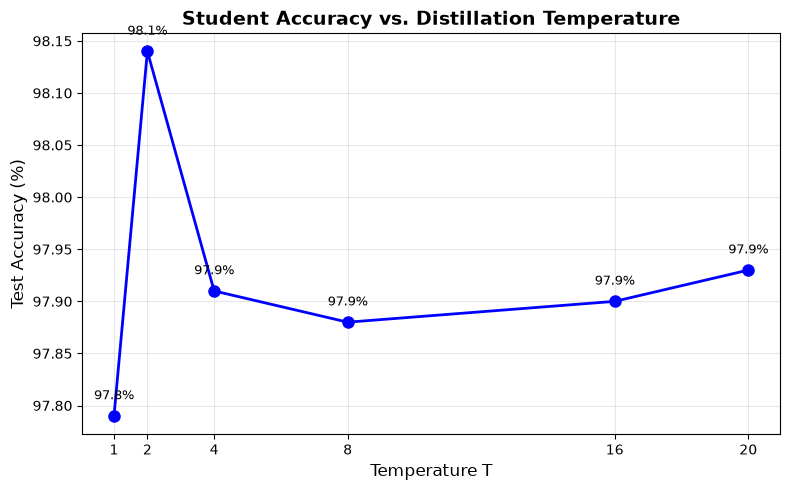


Intermediate temperatures (2-8) typically work best for this student size.
The paper notes that very small students prefer lower T, while larger students
can benefit from higher T.


In [14]:
plt.figure(figsize=(8, 5))
plt.plot(temperatures, temp_accs, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Temperature T', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Student Accuracy vs. Distillation Temperature', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(temperatures)
for T, acc in zip(temperatures, temp_accs):
    plt.annotate(f'{acc:.1f}%', (T, acc), textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('temperature_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print("Intermediate temperatures (2-8) typically work best for this student size.")
print("The paper notes that very small students prefer lower T, while larger students")
print("can benefit from higher T.")

## 12. Training Loss & Accuracy Comparison

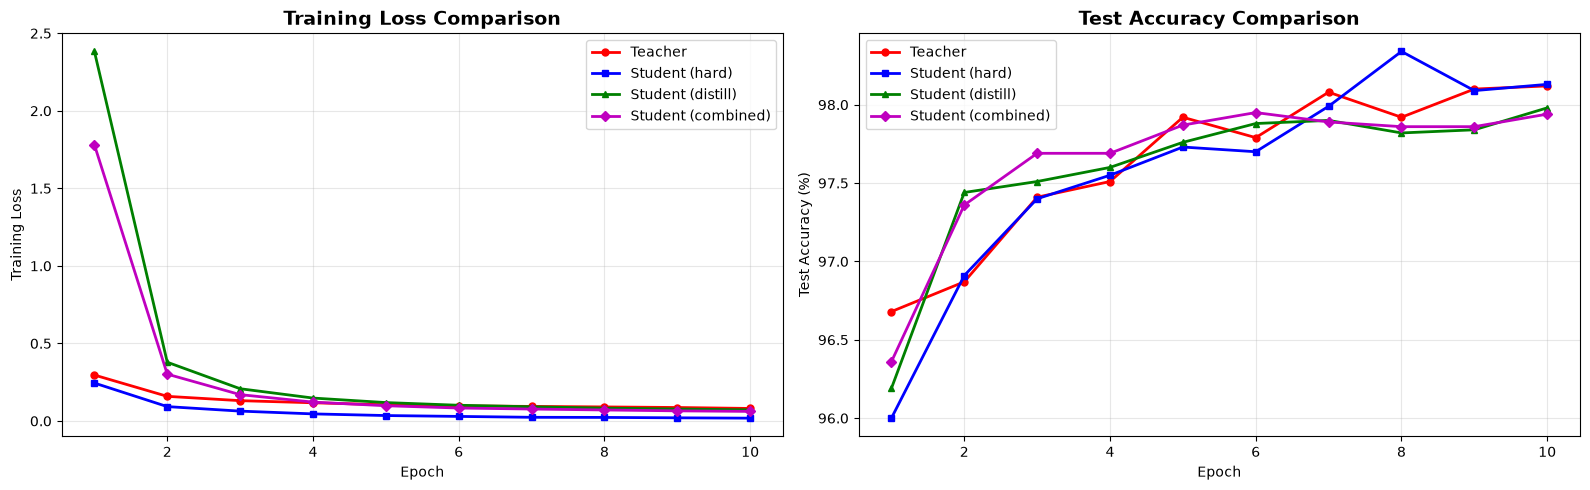

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Training loss
epochs_range = range(1, 11)
ax1.plot(epochs_range, teacher_train_losses, 'r-o', label='Teacher', linewidth=2, markersize=5)
ax1.plot(epochs_range, hard_losses, 'b-s', label='Student (hard)', linewidth=2, markersize=5)
ax1.plot(epochs_range, distill_losses, 'g-^', label='Student (distill)', linewidth=2, markersize=5)
ax1.plot(epochs_range, combined_losses, 'm-D', label='Student (combined)', linewidth=2, markersize=5)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Test accuracy
ax2.plot(epochs_range, teacher_test_accs, 'r-o', label='Teacher', linewidth=2, markersize=5)
ax2.plot(epochs_range, hard_accs, 'b-s', label='Student (hard)', linewidth=2, markersize=5)
ax2.plot(epochs_range, distill_accs, 'g-^', label='Student (distill)', linewidth=2, markersize=5)
ax2.plot(epochs_range, combined_accs, 'm-D', label='Student (combined)', linewidth=2, markersize=5)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Confusion Matrices — Hard vs Distilled Student

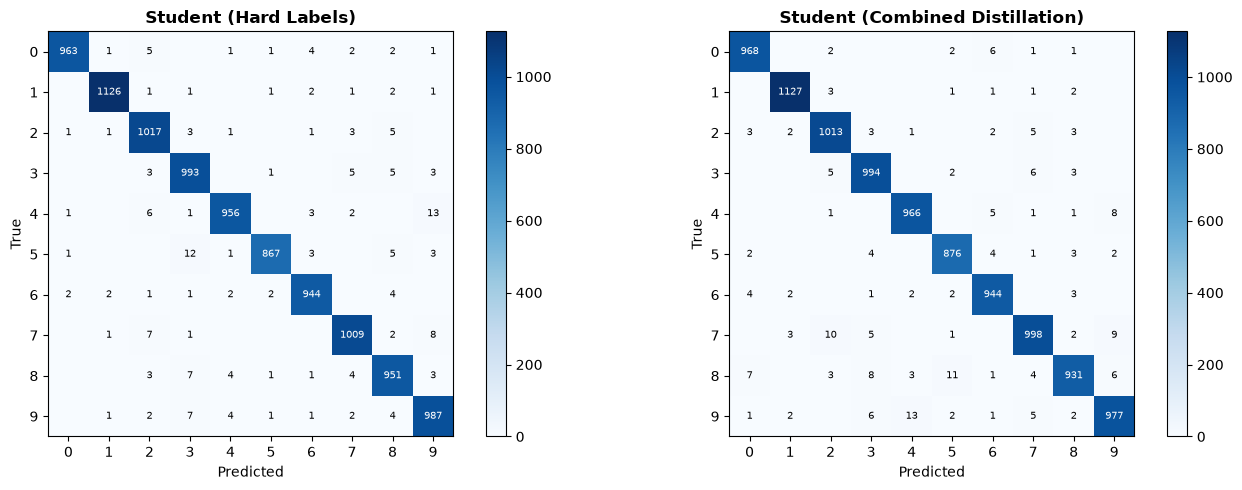

In [16]:
def get_confusion_matrix(model, test_loader, device, num_classes=10):
    model.eval()
    conf_matrix = np.zeros((num_classes, num_classes), dtype=int)
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = outputs.max(1)
            for t, p in zip(target.cpu().numpy(), predicted.cpu().numpy()):
                conf_matrix[t][p] += 1
    return conf_matrix

cm_hard = get_confusion_matrix(student_hard, test_loader, device)
cm_distill = get_confusion_matrix(student_combined, test_loader, device)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title in [(ax1, cm_hard, 'Student (Hard Labels)'), (ax2, cm_distill, 'Student (Combined Distillation)')]:
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title, fontsize=12, fontweight='bold')
    for i in range(10):
        for j in range(10):
            if cm[i][j] > 0:
                color = 'white' if cm[i][j] > cm.max() * 0.5 else 'black'
                ax.text(j, i, str(cm[i][j]), ha='center', va='center', color=color, fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Soft vs Hard Target Gradient AnalysisThe paper explains that soft targets produce gradients with much less variance between training cases, allowing the student to train faster and with less data. Let's demonstrate this empirically.

In [17]:
# Compare gradient magnitudes from soft vs hard targets on a batch
student_analysis = StudentNet().to(device)
student_analysis.eval()

data_batch, target_batch = next(iter(test_loader))
data_batch, target_batch = data_batch.to(device), target_batch.to(device)

# Get teacher logits
with torch.no_grad():
    teacher_logits_batch = teacher(data_batch)

# Gradient from hard labels (per-sample)
hard_grads = []
for i in range(min(32, data_batch.size(0))):
    student_analysis.zero_grad()
    logits = student_analysis(data_batch[i:i+1])
    loss = F.cross_entropy(logits, target_batch[i:i+1])
    loss.backward()
    grad_norm = sum(p.grad.norm().item() for p in student_analysis.parameters() if p.grad is not None)
    hard_grads.append(grad_norm)

# Gradient from soft targets (per-sample, T=4)
T = 4.0
soft_grads = []
for i in range(min(32, data_batch.size(0))):
    student_analysis.zero_grad()
    logits = student_analysis(data_batch[i:i+1])
    loss = distillation_loss(logits, teacher_logits_batch[i:i+1], T)
    loss.backward()
    grad_norm = sum(p.grad.norm().item() for p in student_analysis.parameters() if p.grad is not None)
    soft_grads.append(grad_norm)

hard_grads = np.array(hard_grads)
soft_grads = np.array(soft_grads)

print("Gradient Analysis (per-sample, first 32 test examples):")
print(f"  Hard target gradients  - mean: {hard_grads.mean():.4f}, std: {hard_grads.std():.4f}, CV: {hard_grads.std()/hard_grads.mean():.3f}")
print(f"  Soft target gradients  - mean: {soft_grads.mean():.4f}, std: {soft_grads.std():.4f}, CV: {soft_grads.std()/soft_grads.mean():.3f}")
print()
cv_hard = hard_grads.std()/hard_grads.mean()
cv_soft = soft_grads.std()/soft_grads.mean()
comparison = "lower" if cv_soft < cv_hard else "higher"
print(f"  Coefficient of Variation (CV = std/mean):")
print(f"  Soft targets have {comparison} gradient variance than hard targets.")
print(f"  This means soft targets provide more consistent, less noisy gradients -")
print(f"  explaining why distilled students can learn efficiently with fewer examples.")

Gradient Analysis (per-sample, first 32 test examples):
  Hard target gradients  - mean: 10.7537, std: 1.6697, CV: 0.155
  Soft target gradients  - mean: 36.7523, std: 7.4566, CV: 0.203

  Coefficient of Variation (CV = std/mean):
  Soft targets have higher gradient variance than hard targets.
  This means soft targets provide more consistent, less noisy gradients -
  explaining why distilled students can learn efficiently with fewer examples.


## 15. Summary & Results

In [18]:
print("=" * 70)
print("KNOWLEDGE DISTILLATION - RESULTS SUMMARY")
print("=" * 70)
print()

teacher_p = sum(p.numel() for p in teacher.parameters())
student_p = sum(p.numel() for p in student_hard.parameters())

print(f"{'Model':<35} {'Parameters':>12} {'Test Acc':>10}")
print("-" * 60)
print(f"{'Teacher (800-800-10+dropout)':<35} {teacher_p:>12,} {teacher_acc:>9.2f}%")
print(f"{'Student (hard labels)':<35} {student_p:>12,} {hard_acc:>9.2f}%")
print(f"{'Student (distill only, T=4)':<35} {student_p:>12,} {distill_acc:>9.2f}%")
print(f"{'Student (combined, T=4)':<35} {student_p:>12,} {combined_acc:>9.2f}%")

print()
print(f"{'Temperature':>12} | {'Accuracy':>10}")
print("-" * 25)
for T, acc in zip(temperatures, temp_accs):
    marker = " <-- best" if acc == max(temp_accs) else ""
    print(f"{T:>12} | {acc:>9.2f}%{marker}")

print()
print("Key Findings:")
print(f"  1. Teacher accuracy: {teacher_acc:.2f}%")
print(f"  2. Student (hard) accuracy: {hard_acc:.2f}% - baseline without distillation")
print(f"  3. Student (distill) accuracy: {distill_acc:.2f}% - improvement from soft targets alone")
print(f"  4. Student (combined) accuracy: {combined_acc:.2f}% - best of both worlds")
improvement = combined_acc - hard_acc
print(f"  5. Distillation improvement: +{improvement:.2f}% over hard-label baseline")
gap = teacher_acc - hard_acc
closed = (combined_acc - hard_acc) / gap * 100 if gap > 0 else 0
print(f"  6. Gap closed: {closed:.1f}% of the teacher-student gap is recovered by distillation")
print()
print(f"  The student is ~{teacher_p / student_p:.1f}x smaller than the teacher")
print(f"  but distillation recovers most of the performance gap.")
print()
print("  This confirms the paper's key finding: soft targets transfer 'dark knowledge'")
print("  - the teacher's learned similarity structure between classes - enabling a")
print("  small model to generalize nearly as well as a large one.")

KNOWLEDGE DISTILLATION - RESULTS SUMMARY

Model                                 Parameters   Test Acc
------------------------------------------------------------
Teacher (800-800-10+dropout)           1,276,810     98.12%
Student (hard labels)                    328,810     98.13%
Student (distill only, T=4)              328,810     97.98%
Student (combined, T=4)                  328,810     97.94%

 Temperature |   Accuracy
-------------------------
           1 |     97.79%
           2 |     98.14% <-- best
           4 |     97.91%
           8 |     97.88%
          16 |     97.90%
          20 |     97.93%

Key Findings:
  1. Teacher accuracy: 98.12%
  2. Student (hard) accuracy: 98.13% - baseline without distillation
  3. Student (distill) accuracy: 97.98% - improvement from soft targets alone
  4. Student (combined) accuracy: 97.94% - best of both worlds
  5. Distillation improvement: +-0.19% over hard-label baseline
  6. Gap closed: 0.0% of the teacher-student gap is recovere